In [1]:
#Second seminar notebook
#Uses cleaned data to avoid having to preprocess every time we run it
import pandas as pd
import matplotlib.pyplot as plt
import torch
import sklearn

To save time we will import the preprocessed data using the csv files provided. 

In [2]:
Complete_dataset=pd.read_csv('Cleaned_AIS_Dataset.csv')
one_hot=pd.read_csv('One_Hot.csv')
print(Complete_dataset)

        Unnamed: 0  Unnamed: 0.1       mmsi      navigationalstatus       sog  \
0                0             0  219019621           Unknown value  0.000000   
1                1             1  265628170           Unknown value  0.000000   
2                2             2  219005719           Unknown value  0.000000   
3                3             3  219028066           Unknown value  0.000000   
4                4             4  212584000                  Moored  0.000000   
...            ...           ...        ...                     ...       ...   
358346      358346        387577  236125000  Under way using engine  0.051402   
358347      358347        387578  209717000  Under way using engine  0.077570   
358348      358348        387579  257182000  Under way using engine  0.096262   
358349      358349        387580  219007697           Unknown value  0.163084   
358350      358350        387581  261054050  Under way using engine  0.053738   

             cog   heading 

In [3]:
import torch.nn as nn
Complete_dataset["mmsi"] = Complete_dataset["mmsi"].astype("category").cat.codes
num_vessels = Complete_dataset["mmsi"].nunique()
print(num_vessels)

embedding_dim = 16

embedding = nn.Embedding(num_vessels, embedding_dim)
#Cleaned up Dataset
mmsi_column=Complete_dataset['mmsi']
sog_column=Complete_dataset['sog']
cog_column=Complete_dataset['cog']
heading_column=Complete_dataset['heading']
length_column=Complete_dataset['length']
width_column=Complete_dataset['width']
draught_column=Complete_dataset['draught']
#Next the navigational status one hot encoding
feature_dataset=pd.concat([sog_column,cog_column,heading_column,length_column,width_column,draught_column,one_hot],axis=1)
print(feature_dataset)

3894
             sog       cog   heading    length     width   draught  \
0       0.000000  0.238889  0.238889  0.013043  0.051282  0.000000   
1       0.000000  0.929167  0.000000  0.039130  0.102564  0.000000   
2       0.000000  0.579722  0.000000  0.015942  0.051282  0.000000   
3       0.000000  0.000000  0.000000  0.017391  0.038462  0.000000   
4       0.000000  0.425000  0.294444  0.143478  0.166667  0.247059   
...          ...       ...       ...       ...       ...       ...   
358346  0.051402  0.477500  0.469444  0.118841  0.153846  0.164706   
358347  0.077570  0.948889  0.952778  0.246377  0.346154  0.349020   
358348  0.096262  0.946389  0.947222  0.324638  0.461538  0.270588   
358349  0.163084  0.267222  0.000000  0.010145  0.038462  0.000000   
358350  0.053738  0.875000  0.861111  0.046377  0.102564  0.235294   

        Unnamed: 0  nav_status_Unknown value  nav_status_Moored  \
0                0                         1                  0   
1                1  

In [4]:
class Model(nn.Module):
    def __init__(self, num_vessels, embedding_dim, num_numeric_features):
        super().__init__()

        self.mmsi_embed = nn.Embedding(
            num_embeddings=num_vessels,
            embedding_dim=embedding_dim
        )

        self.input_dim = embedding_dim + num_numeric_features+1 
        
        self.fc1 = nn.Linear(self.input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 17)
        
    def forward(self, mmsi, numeric_features):
        mmsi_emb = self.mmsi_embed(mmsi).squeeze(1)
        #print("mmsi_emb shape:", mmsi_emb.shape)
        #print("numeric_features shape:", numeric_features.shape)
        x = torch.cat([mmsi_emb, numeric_features], dim=1)
        #print("x shape after concat:", x.shape)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = self.fc4(x) 
        return x

In [5]:
shipType=Complete_dataset['shiptype']
print(shipType)
import sklearn as sk
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import TensorDataset, DataLoader

mmsi_data=Complete_dataset['mmsi']
mmsi_encoder = LabelEncoder()
mmsi_encoded = mmsi_encoder.fit_transform(Complete_dataset['mmsi'])
X_mmsi_train, X_mmsi_test, \
X_num_train, X_num_test, \
y_train, y_test = sk.model_selection.train_test_split(
    mmsi_encoded,
    feature_dataset,
    shipType,
    test_size=0.1,
    shuffle=True
)

X_mmsi_train, X_mmsi_val, \
X_num_train, X_num_val, \
y_train, y_val = sk.model_selection.train_test_split(
    X_mmsi_train,
    X_num_train,
    y_train,
    test_size=0.1,
    shuffle=True
)
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc=le.transform(y_test)
#Next we need to feed these into the basic pytorch model

X_mmsi_train_t = torch.tensor(X_mmsi_train, dtype=torch.long)
X_mmsi_val_t   = torch.tensor(X_mmsi_val, dtype=torch.long)
X_mmsi_test_t=torch.tensor(X_mmsi_test,dtype=torch.long)

X_num_train_t = torch.tensor(X_num_train.to_numpy(), dtype=torch.float32)
X_num_val_t   = torch.tensor(X_num_val.to_numpy(), dtype=torch.float32)
X_num_test_t=torch.tensor(X_num_test.to_numpy(),dtype=torch.float32)
y_train_t = torch.tensor(y_train_enc, dtype=torch.long)
y_val_t   = torch.tensor(y_val_enc, dtype=torch.long)
y_test_t=torch.tensor(y_test_enc,dtype=torch.long)
train_dataset = TensorDataset(
    X_mmsi_train_t,
    X_num_train_t,
    y_train_t
)

val_dataset = TensorDataset(
    X_mmsi_val_t,
    X_num_val_t,
    y_val_t
)
test_dataset=TensorDataset( X_mmsi_test_t,X_num_test_t,y_test_t)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=False)
val_dataloader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_dataloader=DataLoader(test_dataset,batch_size=32,shuffle=False)

0             Fishing
1         Port tender
2             Fishing
3            Pleasure
4               Cargo
             ...     
358346          Cargo
358347          Cargo
358348      Passenger
358349          Pilot
358350        Fishing
Name: shiptype, Length: 358351, dtype: object


In [6]:
training_epochs=10
num_vessels = len(mmsi_encoder.classes_)
assert X_mmsi_train_t.min() >= 0
assert X_mmsi_train_t.max() < num_vessels
assert X_mmsi_val_t.min() >= 0
assert X_mmsi_val_t.max() < num_vessels
net_nn=Model(num_vessels,16,15)
optimizer = torch.optim.Adam(net_nn.parameters(), lr=1e-3)
net_nn = Model(num_vessels, embedding_dim, 15)
optimizer = torch.optim.Adam(net_nn.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

mmsi, numeric, labels = next(iter(train_dataloader))
print("mmsi range:", mmsi.min().item(), mmsi.max().item())
print("labels:", torch.unique(labels))
print("numeric sample:\n", numeric[:3])

for i in range(200):
    optimizer.zero_grad()
    outputs = net_nn(mmsi, numeric)
    loss = criterion(outputs, labels.long())
    loss.backward()
    optimizer.step()
    if i % 20 == 0:
        preds = outputs.argmax(dim=1)
        print(f"Step {i} | Loss: {loss.item():.4f} | Preds: {preds[:8].tolist()} | Labels: {labels[:8].tolist()}")

        

mmsi range: 185 3772
labels: tensor([ 0,  1,  2,  5,  6, 12, 13])
numeric sample:
 tensor([[3.4579e-02, 8.6694e-01, 8.6944e-01, 1.7246e-01, 1.7949e-01, 1.7647e-01,
         3.1462e+04, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [6.5888e-02, 1.6972e-01, 1.7500e-01, 1.4638e-01, 2.3077e-01, 2.3137e-01,
         1.5689e+05, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [6.5421e-02, 5.8056e-01, 5.7778e-01, 3.4348e-01, 4.1026e-01, 4.0784e-01,
         2.4410e+05, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00]])
Step 0 | Loss: 3308.9404 | Preds: [6, 6, 6, 6, 6, 6, 6, 6] | Labels: [0, 0, 0, 0, 0, 6, 0, 0]
Step 20 | Loss: 27.1561 | Preds: [13, 13, 13, 13, 13, 13, 13, 13] | Labels: [0, 0, 0, 0, 0, 6, 0, 0]
Step 40 | Loss: 36.5982 | Preds: [0, 0, 0, 0, 0, 0, 0, 0] | L

Epoch 3/10, Loss: 1.5859
Counter({0: 12, 13: 8, 2: 3, 6: 2, 11: 2, 5: 1, 12: 1, 15: 1, 7: 1, 16: 1})
Counter({0: 30, 13: 12, 2: 6, 6: 5, 5: 2, 7: 2, 11: 2, 12: 1, 15: 1, 16: 1, 8: 1, 1: 1})
Counter({0: 47, 13: 20, 2: 8, 6: 7, 5: 3, 11: 3, 7: 2, 12: 1, 15: 1, 16: 1, 8: 1, 1: 1, 3: 1})
Counter({0: 61, 13: 32, 2: 11, 6: 8, 5: 3, 11: 3, 15: 2, 7: 2, 1: 2, 12: 1, 16: 1, 8: 1, 3: 1})
Counter({0: 82, 13: 37, 2: 13, 6: 9, 5: 3, 12: 3, 11: 3, 1: 3, 15: 2, 7: 2, 16: 1, 8: 1, 3: 1})
Counter({0: 97, 13: 43, 2: 18, 6: 11, 1: 5, 5: 3, 12: 3, 11: 3, 15: 2, 7: 2, 16: 2, 8: 2, 3: 1})
Counter({0: 116, 13: 52, 2: 20, 6: 12, 1: 5, 5: 3, 12: 3, 16: 3, 11: 3, 15: 2, 7: 2, 8: 2, 3: 1})
Counter({0: 130, 13: 59, 2: 24, 6: 13, 16: 5, 1: 5, 7: 4, 11: 4, 5: 3, 12: 3, 8: 3, 15: 2, 3: 1})
Counter({0: 147, 13: 68, 2: 24, 6: 15, 16: 6, 11: 5, 1: 5, 5: 4, 7: 4, 12: 3, 8: 3, 15: 2, 3: 1, 10: 1})
Counter({0: 167, 13: 75, 2: 25, 6: 16, 16: 6, 11: 6, 7: 5, 1: 5, 5: 4, 12: 3, 8: 3, 15: 2, 3: 1, 10: 1, 14: 1})
Counter({0: 1

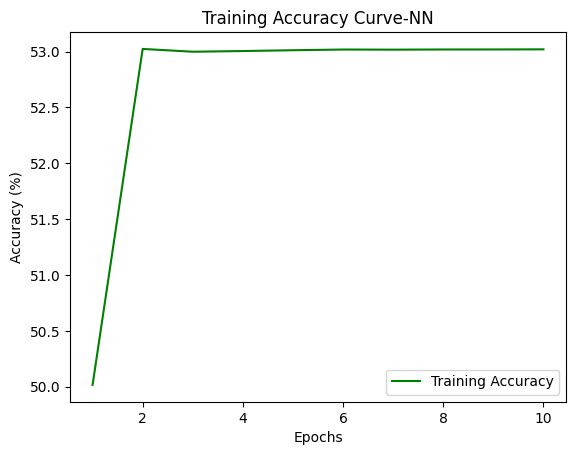

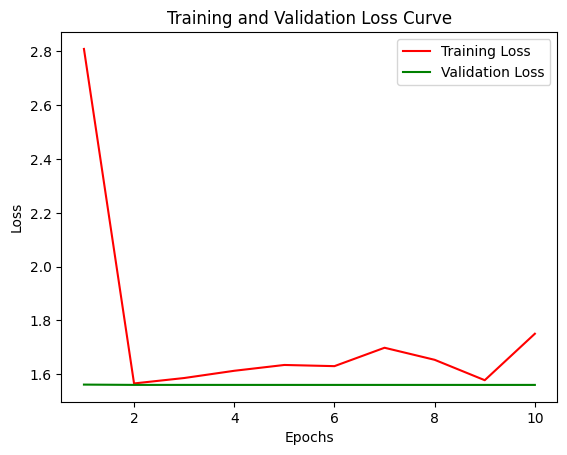

In [7]:
train_losses=[]
accuracies=[]
val_losses=[]
for epoch in range(training_epochs):  
    running_loss = 0.0
    net_nn.train()
    train_accuracy=0
    train_total=0
    train_correct=0
    for mmsi, numeric, labels in train_dataloader:
        optimizer.zero_grad()
        outputs = net_nn(mmsi,numeric)
        #print(mmsi)
        #print(numeric)
        labels = labels.long()
        #print(labels)
        criterion=nn.CrossEntropyLoss()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        predicted = outputs.argmax(dim=1)
        #print(predicted)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
        running_loss += loss.item()
    #print(running_loss)
    train_losses.append(running_loss/len(train_dataloader))
    print(f"Epoch {epoch+1}/{training_epochs}, Loss: {running_loss/len(train_dataloader):.4f}")
    train_accuracy = 100 * train_correct / train_total
    accuracies.append(train_accuracy)
    all_val_labels = []
    all_val_predictions = []
    val_total=0
    val_correct=0
    val_accuracy=0
    val_running_loss=0
    with torch.no_grad():
        val_total=0
        val_correct=0
        val_accuracy=0
        running_loss=0.0
        for mmsi_val, numeric_val, labels_val in val_dataloader:
            net_nn.eval()
            outputs_val = net_nn(mmsi_val,numeric_val) 
            labels_val = labels_val.long()
            predicted_val = outputs_val.argmax(dim=1)
            all_val_labels.extend(labels_val.cpu().numpy())
            all_val_predictions.extend(predicted_val.cpu().numpy())
            val_total += labels_val.size(0)
            loss = criterion(outputs_val, labels_val)
            val_running_loss += loss.item()
            val_correct += (predicted_val == labels_val).sum().item()
        val_accuracy = 100 * val_correct / val_total
        val_losses.append(val_running_loss/len(val_dataloader))
    print(f"Val Accuracy: {val_accuracy:.2f}%")
print('Finished Training')

#Next we evaluate the RNN model quickly
plt.plot(range(1, training_epochs + 1), accuracies, label="Training Accuracy", color="green")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Training Accuracy Curve-NN")
plt.legend()
plt.savefig('accuracy_graph_nn.png')
plt.show()
plt.plot(range(1, training_epochs + 1), train_losses, label="Training Loss", color="red")
plt.plot(range(1, training_epochs + 1), val_losses, label="Validation Loss", color="green")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Curve")
plt.legend()
plt.savefig('Loss_graph_NN.png')
plt.show()
#Next we need to add testing accuracy and confusion matrix to this analysis

Test Accuracy: 52.97%


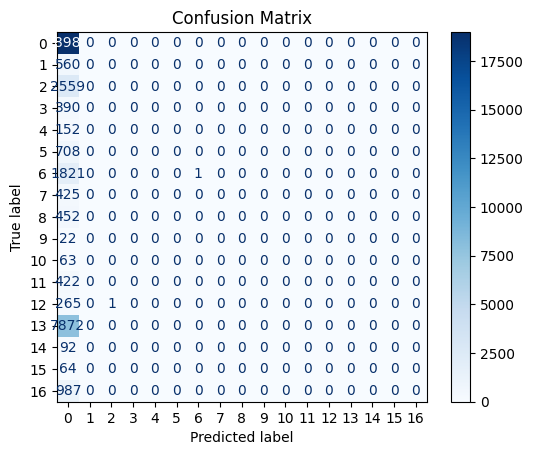

In [8]:
net_nn.eval()
test_total=0
test_correct=0
test_accuracy=0
all_test_labels = []
all_test_predictions = []
test_accuracies=[]
with torch.no_grad():
    for mmsi, numeric, labels in test_dataloader:
            outputs = net_nn(mmsi,numeric) 
            labels = labels.long()
            predicted = outputs.argmax(dim=1)
            all_test_labels.extend(labels.cpu().numpy())
            all_test_predictions.extend(predicted.cpu().numpy())
            test_total += labels.size(0)
            running_loss += loss.item()
            test_correct += (predicted == labels).sum().item()
        
    accuracy = 100 * test_correct / test_total
    print(f"Test Accuracy: {accuracy:.2f}%")
    test_accuracies.append(test_accuracy)
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    import matplotlib.pyplot as plt
    
    cm = confusion_matrix(all_test_labels, all_test_predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.show()

In [9]:
#Support Vector Machine Implementation
#Embedding code for all the features

model.eval()
embeddings = []
labels = []

for x, y in dataloader:
    z = model(x)
    embeddings.append(z.detach().numpy())
    labels.append(y.numpy())

svm = SVC(kernel='rbf')
svm.fit(embeddings, labels)
from sklearn.metrics import accuracy_score
SVM_val_preds = svm.predict(X_val_svm)
print(f"Val Accuracy: {accuracy_score(y_val_enc, val_preds) * 100:.2f}%")

#Random Forest
RF=sklearn.ensemble.RandomForestClassifier()
RF.fit(embeddings,labels)
RF_val_preds=RF.predict(X_val_sum)

#Decision Tree
DT= sklearn.tree.DecisionTreeClassifier()
DT_val_preds=DT.predict(X_val_sum)


#K-NN
KNN=sklearn.neighbors.KNeighborsClassifier()
KNN.fit(embeddings,labels)



#Transformer
#How can we use a transformer when we don't have temporal data?


NameError: name 'model' is not defined

To evaluate a classifier we can use many metrics, and frequently we use multiple metrics simultaneously. For example accuracy is not the only metric we should consider, especially when we have imbalanced classes. An example of this would be a classifier to detect cancer, if most of the patient population we are testing does not have cancer and our classifier just labels everyone as negative (does not have cancer) we will have a reasonably high accuracy. However, this classifier is useless for its assigned role. In terms the specific case we have here in terms of AIS detection we use multiple metrics to determine the performance of our classifier.

A common method for visualization results for a pattern classification task is to use something called a confusion matrix, this shows exactly what decisions are classifier is making and is particularly useful to see what classes the classifier is mixing up. The confusion matrix for each of our classifiers on the test set are shown in the plots below.

In [ ]:
#Confusion Matrix here
cm_val = confusion_matrix(all_val_labels, all_val_predictions)
plt.figure(figsize=(6, 5))
#sns.heatmap(cm_val, annot=True, fmt='d', cmap="Blues", xticklabels=range(len(cm_val)), yticklabels=range(len(cm_val)))
#plt.xlabel('Predicted Label')
#plt.ylabel('True Label')
#plt.title('Confusion Matrix RNN')
#plt.savefig('conf_matrix_rnn_val.png')
#plt.show()

We can obtain metrics using various software libraries, however it is useful to understand where these metrics come from. In the case of a binary classification problem where there are True positives (TP), True Negatives (TN), False Positives (FP) and False Negatives (FN) we can define the metrics as follows:
Accuracy = (TP+TN) / (TP+TN+FN+FP)
Sensitivity = Sn = TP / (TP+FN)
Specificity = Sp = TN / (TN+FP)
False Positive Rate = 1-Sp
False Negative Rate = 1-Sn
Positive Predictive Value = TP / (TP+FP)
Negative Predictive Value = TN / (TN+FN)

This becomes a bit trickier with the multi-class situation we have, but you can still evaluate on a per-class basis and take averages to determine the performance of your classifier. In addition, there are robust metrics such as F1 score.


In [ ]:
#F1 score, precision, sensitivity, recall


In [ ]:
#ROC curve potentially